In [1]:
# 캘리포니아 주택 데이터 셋
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 데이터 로드
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 데이터 분리
x_train_full, x_test, y_train_full, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_full, y_train_full, test_size=0.25, random_state=42)

# 데이터 형태 확인
x_train.shape, x_valid.shape, x_test.shape

((11610, 8), (3870, 8), (5160, 8))

In [2]:
# 훈련데이터로 가중치 학습
# 미니배치 경사하강법 + 역전파
# 손실을 줄이도록 파라메터를 반복 업데이트

In [3]:
import tensorflow as tf

tf.random.set_seed(42)

# 정규화 레이어
normal_layer = tf.keras.layers.Normalization(input_shape=(8,))

# 모델
model = tf.keras.Sequential([
    normal_layer,
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(1),
])

# 컴파일 (오타 수정)
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['RootMeanSquaredError']
)

# 반드시 fit 전에 실행
normal_layer.adapt(x_train)

# 학습
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_valid, y_valid))

Epoch 1/20


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 1.0575 - loss: 1.1184 - val_RootMeanSquaredError: 0.6719 - val_loss: 0.4514
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.6266 - loss: 0.3926 - val_RootMeanSquaredError: 0.9383 - val_loss: 0.8804
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6006 - loss: 0.3607 - val_RootMeanSquaredError: 0.9291 - val_loss: 0.8633
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5873 - loss: 0.3450 - val_RootMeanSquaredError: 0.6210 - val_loss: 0.3857
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5808 - loss: 0.3373 - val_RootMeanSquaredError: 0.5730 - val_loss: 0.3283
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6019 - loss: 0.3623 - val_RootMeanSquaredError: 2.3855 - val_loss: 5.6907
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5700 - loss: 0.3249 -

In [4]:
# 성능측정
model.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - RootMeanSquaredError: 0.5284 - loss: 0.2792


[0.27916407585144043, 0.5283597707748413]

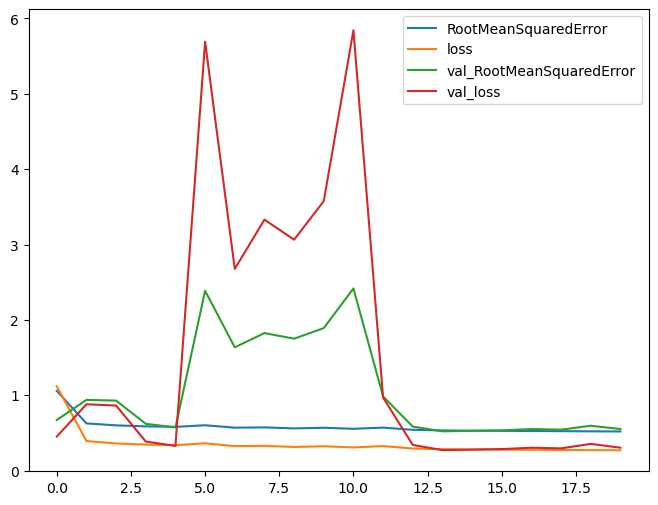

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(20), history.history['RootMeanSquaredError'], label='RootMeanSquaredError')
plt.plot(range(20), history.history['loss'], label='loss')
plt.plot(range(20), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
plt.plot(range(20), history.history['val_loss'], label='val_loss')
plt.legend()

In [6]:
from sklearn.metrics import r2_score
y_predcit = model.predict(x_test)
r2_score(y_test, y_predcit)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step


0.789026405164125

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

sk_model = RandomForestRegressor(random_state=42)
sk_model.fit(x_train, y_train)
sk_y_pred = sk_model.predict(x_test)
r2_score(y_test, sk_y_pred)

# 단순한 데이터셋은 머신러닝이 훨씬 효과적이다

0.8001601142626265

In [8]:
# 함수형 api를 사용한 복잡한 모델 구축
# 와이드 & 딥 신경망 : 입력의 전부 또는 일부를 출력레이어 직접 연결
# 선형관계 / 비선형표현 동시 학습 -> 편향 / 분산 균형 맞춤
# 저차원과 고차원 정보를 합쳐 정보 손실 줄임

In [17]:
import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(42)
input = tf.keras.layers.Input(shape=x_train.shape[1:])
normalization_layer = tf.keras.layers.Normalization()
hidden_layer1 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer2 = tf.keras.layers.Dense(50, activation='relu')
hidden_layer3 = tf.keras.layers.Dense(50, activation='relu')
output_layer = tf.keras.layers.Dense(1)
concat_layer = tf.keras.layers.Concatenate()

nomalized = normalization_layer(input)
hidden1 = hidden_layer1(nomalized)
hidden2 = hidden_layer2(hidden1)
hidden3 = hidden_layer3(hidden2)
concat = concat_layer([nomalized, hidden3])
output = output_layer(concat)

model = tf.keras.Model(inputs=[input], outputs=[output])
# 파라메터 개수 확인
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 8)         │         17 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        450 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      2,550 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50)        │      2,550 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 58)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         59 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,626 (21.98 KB)

 Trainable params: 5,609 (21.91 KB)

 Non-trainable params: 17 (72.00 B)

In [18]:
# 컴파일
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['RootMeanSquaredError']
)

# 반드시 fit 전에 실행
normalization_layer.adapt(x_train)

# 학습
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - RootMeanSquaredError: 0.9521 - loss: 0.9064 - val_RootMeanSquaredError: 0.6155 - val_loss: 0.3788
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.6143 - loss: 0.3773 - val_RootMeanSquaredError: 0.5893 - val_loss: 0.3473
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5944 - loss: 0.3533 - val_RootMeanSquaredError: 0.8449 - val_loss: 0.7138
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5790 - loss: 0.3352 - val_RootMeanSquaredError: 1.1100 - val_loss: 1.2322
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5720 - loss: 0.3271 - val_RootMeanSquaredError: 0.7666 - val_loss: 0.5876
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.5607 - loss: 0.3144 - val_RootMeanSquaredError: 1.0460 - val_loss: 1.0941
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5580 - los

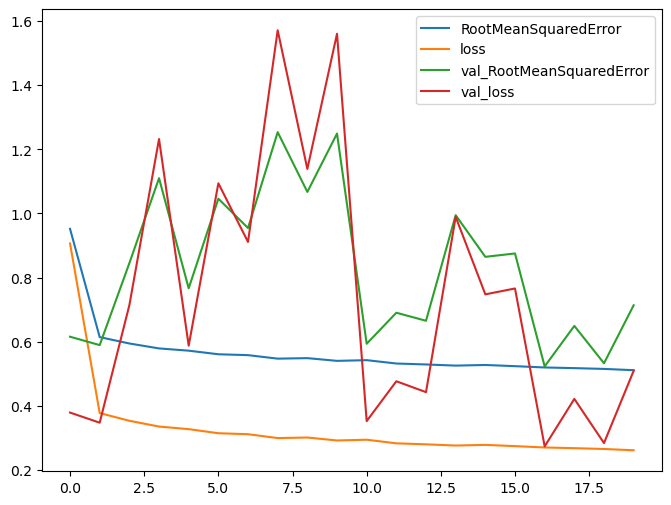

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(20), history.history['RootMeanSquaredError'], label='RootMeanSquaredError')
plt.plot(range(20), history.history['loss'], label='loss')
plt.plot(range(20), history.history['val_RootMeanSquaredError'], label='val_RootMeanSquaredError')
plt.plot(range(20), history.history['val_loss'], label='val_loss')
plt.legend()

In [20]:
from sklearn.metrics import r2_score
y_predcit = model.predict(x_test)
r2_score(y_test, y_predcit)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step


0.7859761893648433

In [7]:
import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(42)

x_train_wide, x_train_deep = x_train[:, :5], x_train[:, 2:]
x_val_wide, x_val_deep = x_valid[:, :5], x_valid[:, 2:]
x_test_wide, x_test_deep = x_test[:, :5], x_test[:, 2:]

input_wide = tf.keras.layers.Input(shape=[5]) # 0~4 특성
input_deep = tf.keras.layers.Input(shape=[6]) # 2~7
normal_layer_wide = tf.keras.layers.Normalization()
normal_layer_deep = tf.keras.layers.Normalization()
norm_wide = normal_layer_wide(input_wide)
norm_deep = normal_layer_deep(input_deep)

hidden1 = tf.keras.layers.Dense(30, activation='relu')(norm_deep)
hidden2 = tf.keras.layers.Dense(30, activation='relu')(hidden1)

concat = tf.keras.layers.concatenate([norm_wide, hidden2])
output = tf.keras.layers.Dense(1)(concat)

aux_output = tf.keras.layers.Dense(1)(hidden2)

model = tf.keras.Model(inputs = [input_wide, input_deep], outputs = [output, aux_output])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss=('mse','mse'), loss_weights=(0.9,0.1), optimizer=optimizer,
              metrics=['RootMeanSquaredError','RootMeanSquaredError'])

normal_layer_wide.adapt(x_train_wide)
normal_layer_deep.adapt(x_train_deep)

history = model.fit(
    (x_train_wide, x_train_deep), (y_train, y_train), epochs=20,
    validation_data=((x_val_wide, x_val_deep),(y_valid, y_valid))
)

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - dense_2_RootMeanSquaredError: 1.3248 - dense_2_loss: 1.7544 - dense_3_RootMeanSquaredError: 1.3741 - dense_3_loss: 1.8877 - loss: 1.7683 - val_dense_2_RootMeanSquaredError: 0.8204 - val_dense_2_loss: 0.6729 - val_dense_3_RootMeanSquaredError: 2.6868 - val_dense_3_loss: 7.2154 - val_loss: 1.3276
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_2_RootMeanSquaredError: 0.7501 - dense_2_loss: 0.5626 - dense_3_RootMeanSquaredError: 0.8440 - dense_3_loss: 0.7123 - loss: 0.5776 - val_dense_2_RootMeanSquaredError: 0.6973 - val_dense_2_loss: 0.4861 - val_dense_3_RootMeanSquaredError: 1.7810 - val_dense_3_loss: 3.1704 - val_loss: 0.7548
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - dense_2_RootMeanSquaredError: 0.6885 - dense_2_loss: 0.4740 - dense_3_RootMeanSquaredError: 0.7662 - dense_3_loss: 0.5871 - loss: 0.4853 - val_dense_2_RootMeanSquaredError: 0.6494 - val_dense_2_loss: 0.4216 - val_dense_3_RootMeanSquaredError: 1.2

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 6)         │         13 │ input_layer_1[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        210 │ normalization_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 5)         │         11 │ input_layer[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 35)        │          0 │ normalization[0]… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         36 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         31 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,647 (14.26 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 24 (104.00 B)

 Optimizer params: 2,416 (9.44 KB)

In [12]:
model.evaluate( (x_test_wide, x_test_deep), (y_test, y_test))

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - dense_2_RootMeanSquaredError: 0.5764 - dense_2_loss: 0.3321 - dense_3_RootMeanSquaredError: 0.6313 - dense_3_loss: 0.3990 - loss: 0.3389  


[0.33888062834739685,
 0.33205726742744446,
 0.3990391492843628,
 0.5764163732528687,
 0.6312726736068726]

In [15]:
model.predict( (x_test_wide, x_test_deep) )

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


[array([[0.35408008],
        [1.11355   ],
        [3.6059132 ],
        ...,
        [1.5622332 ],
        [2.3787305 ],
        [3.8946898 ]], dtype=float32),
 array([[0.37338585],
        [0.97753817],
        [3.4205847 ],
        ...,
        [1.6227119 ],
        [2.0536342 ],
        [3.5524886 ]], dtype=float32)]